# Quantum Error Correction via Entanglement Distillation 
https://arxiv.org/abs/1810.03267 (Apendix A)

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.classical import expr

def create_bell_pair(qc, i):
    qc.h(i)
    qc.cx(i, i + 1)
    
def long_distance_cnot(qc, control, target):

    if control == target:
        raise ValueError("Control and target qubits must be different.")

    if abs(control - target) == 1:
        qc.cx(control, target)

    elif control < target:
        qc.swap(control, control + 1)
        long_distance_cnot(qc, control + 1, target)
        qc.swap(control, control + 1) 
        
    else:
        qc.swap(control, control - 1)
        long_distance_cnot(qc, control - 1, target)
        qc.swap(control, control - 1)

In [11]:
n_exchanged_pairs = 3 

def generate_qec_circuit(n_exchanged_pairs):
    if n_exchanged_pairs < 3:
        raise ValueError("Number of exchanged pairs must be at least 3.")

    n_pure_pairs = n_exchanged_pairs-1

    n_qubits = 2 * n_exchanged_pairs 
    n_ancilla_qubits = n_pure_pairs*2 
    n_total_qubits = n_qubits + n_ancilla_qubits

    n_classical_bits = n_pure_pairs

    qc = QuantumCircuit(n_total_qubits, n_classical_bits)
    
    # Create pure bell pairs
    qc.barrier()
    for i in range(2, n_total_qubits - 2, 2):
        create_bell_pair(qc, i)

    # Create bell pairs to simulate the exchange of qubits between Alice and Bob
    qc.barrier()
    for i in range(0, n_total_qubits, 4):
        create_bell_pair(qc, i)
    

    # Parity check for bit flip error correction
    qc.barrier()
    long_distance_cnot(qc, 0, 2)
    long_distance_cnot(qc, 1, 3)

    for i in range(4, n_total_qubits-5, 4):
        long_distance_cnot(qc, i, i - 2)
        long_distance_cnot(qc, i, i + 2)

        long_distance_cnot(qc, i+1, i + 1 - 2)
        long_distance_cnot(qc, i+1, i + 1 + 2)
        
    long_distance_cnot(qc, n_total_qubits-2, n_total_qubits-4)
    long_distance_cnot(qc, n_total_qubits-1, n_total_qubits-3)

    qc.barrier()

    for i in range(n_pure_pairs):
        print(i)
        qc.measure(2 + i*4, i)
        qc.measure(2 + i*4 + 1, i)

    return qc   



0
1


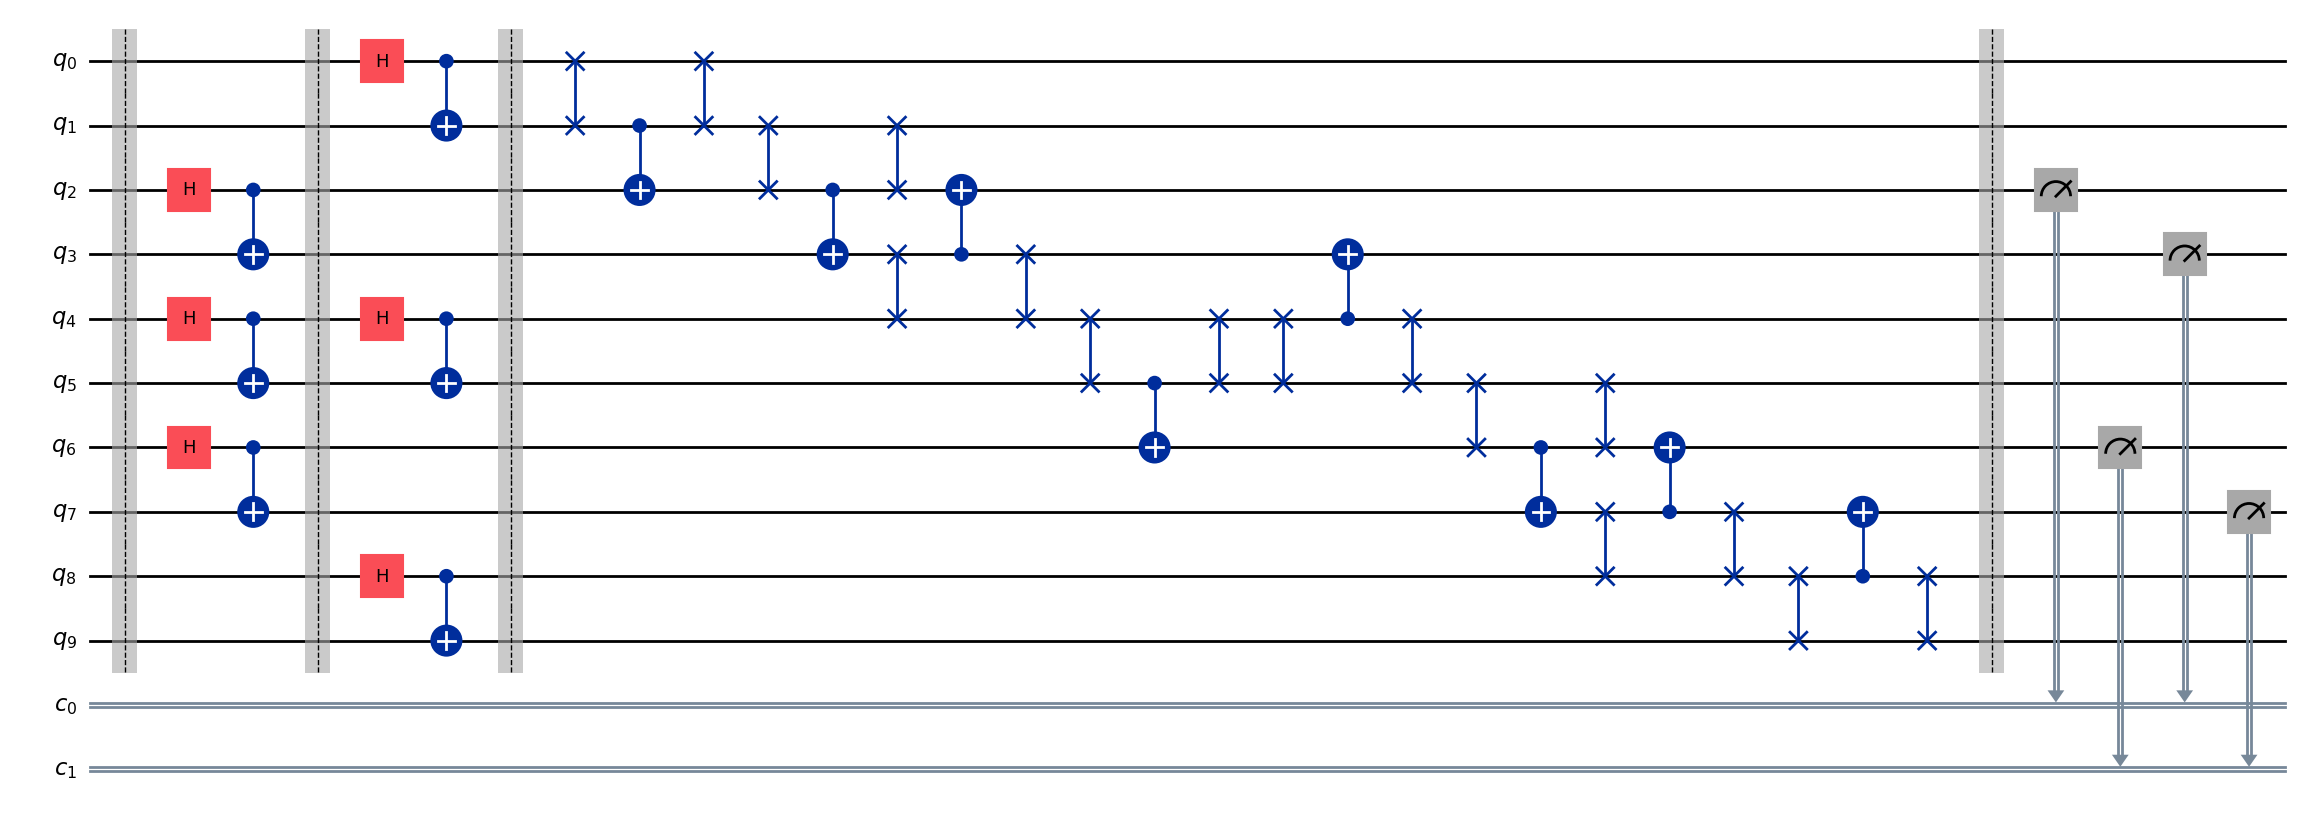

In [12]:
n_exchanged_pairs = 3
qc = generate_qec_circuit(n_exchanged_pairs)
qc.draw(output='mpl', cregbundle=False, fold = -1)